# Traditional CV

In [1]:
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
import cv2


# Load dataset and extract HOG features
mnist = fetch_openml('mnist_784', version=1)
dataset = zip(mnist.data.to_numpy().reshape(-1, 28, 28), mnist.target.to_numpy().astype(int))

def extract_hog_features(image):
    features, _ = hog(image, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=True)
    return features

X, y = [], []  # Features and labels
for image, label in dataset:
    X.append(extract_hog_features(image))
    y.append(label)

# Train SVM classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf = LinearSVC()
clf.fit(X_train, y_train)

# Test on new image
prediction = clf.predict([X[0]])
print("Predicted class:", prediction)

Predicted class: [5]


## Modern CV

In [1]:
import torch

# Load pre-trained YOLOv5 model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

# Perform inference on an image
image_path = "1.jpeg"
results = model(image_path)

# Display results
results.print()  # Print detected objects and confidence scores
results.show()   # Show image with bounding boxes

Using cache found in /home/aliakbar/.cache/torch/hub/ultralytics_yolov5_master


  Using cached torchvision-0.21.0-cp311-cp311-manylinux1_x86_64.whl.metadata (6.1 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
  Using cached torch-2.6.0-cp311-cp311-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.meta

ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device



PackageNotFoundError: No package metadata was found for torchvision

## Convolution Layer

In [2]:
import numpy as np
import tensorflow as tf


array = tf.constant([[
    [1, 2, 3, 1, 2, 3, 1, 2, 3],
    [4, 5, 6, 4, 5, 6, 4, 5, 6],
    [7, 8, 9, 7, 8, 9, 7, 8, 9],
]])
array = tf.expand_dims(array, axis=-1)

# 10 filter
conv_layer = tf.nn.conv2d(array, np.ones([3, 3, 1, 10]), strides=np.ones([1, 1, 1, 1]), padding='VALID')


conv_layer

2025-03-31 10:12:03.655836: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-31 10:12:08.012384: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


<tf.Tensor: shape=(1, 1, 7, 10), dtype=int32, numpy=
array([[[[45, 45, 45, 45, 45, 45, 45, 45, 45, 45],
         [45, 45, 45, 45, 45, 45, 45, 45, 45, 45],
         [45, 45, 45, 45, 45, 45, 45, 45, 45, 45],
         [45, 45, 45, 45, 45, 45, 45, 45, 45, 45],
         [45, 45, 45, 45, 45, 45, 45, 45, 45, 45],
         [45, 45, 45, 45, 45, 45, 45, 45, 45, 45],
         [45, 45, 45, 45, 45, 45, 45, 45, 45, 45]]]], dtype=int32)>

## Maxpooling Layer

In [2]:
import numpy as np
import tensorflow as tf


array = tf.constant([[
    [1, 2, 3, 1, 2, 3, 1, 2],
    [4, 5, 6, 4, 5, 6, 4, 5]
]])
array = tf.expand_dims(array, axis=-1)

pool_layer = tf.nn.max_pool2d(array, (2, 2), (1, 1), padding='VALID')

pool_layer

<tf.Tensor: shape=(1, 1, 7, 1), dtype=int32, numpy=
array([[[[5],
         [6],
         [6],
         [5],
         [6],
         [6],
         [5]]]], dtype=int32)>

## CNN Architecture

### MNIST Example

In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input


def load_data():
    (train, train_y), (test, test_y) = mnist.load_data()
    train = train / 255
    test = test / 255
    return train, train_y, test, test_y

def build_model():
    model = Sequential(
        [
            Input((28, 28, 1)),
            Conv2D(32, (3, 3), activation='relu'),
            MaxPooling2D(),
            Conv2D(64, (3, 3), activation='relu'),
            Flatten(),
            Dense(256, activation='relu'),
            Dense(10, activation='softmax')
        ]
    )
    return model

X, y, X_test, y_test = load_data()

model = build_model()
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 flatten (Flatten)           (None, 7744)              0         
                                                                 
 dense (Dense)               (None, 256)               1982720   
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                        

In [4]:
model.fit(X, y, validation_split=.2, batch_size=16, epochs=3, verbose=2)

Epoch 1/3
3000/3000 - 181s - loss: 0.1090 - accuracy: 0.9659 - val_loss: 0.0569 - val_accuracy: 0.9833 - 181s/epoch - 60ms/step
Epoch 2/3
3000/3000 - 131s - loss: 0.0389 - accuracy: 0.9887 - val_loss: 0.0479 - val_accuracy: 0.9860 - 131s/epoch - 44ms/step
Epoch 3/3
3000/3000 - 186s - loss: 0.0250 - accuracy: 0.9925 - val_loss: 0.0453 - val_accuracy: 0.9878 - 186s/epoch - 62ms/step


In [5]:
import matplotlib.pyplot as plt
image = tf.expand_dims(X[0], axis=0)
feature_maps = []
for layer in model.layers[:-2]:
    feature_maps.append(tf.keras.models.Model(inputs=model.input, outputs=layer.output)(image))
    print(layer)

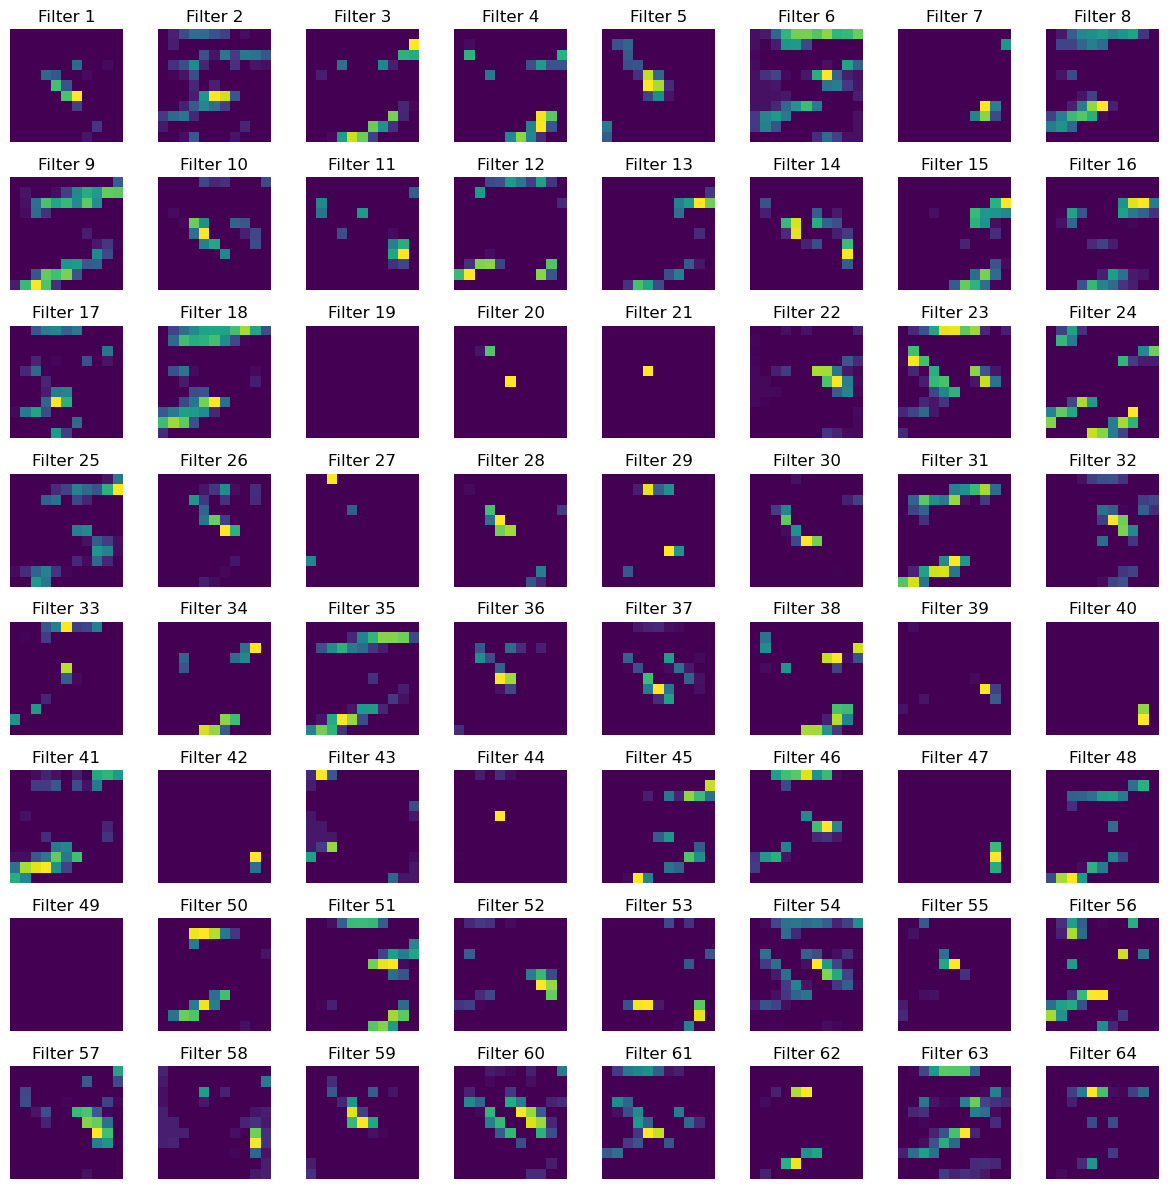

In [6]:
feature_map = feature_maps[2][0]

# Number of filters
num_filters = feature_map.shape[-1]

# Plot each filter in a grid
grid_size = int(np.ceil(np.sqrt(num_filters)))  # Determine grid size

fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < num_filters:
        # Display the i-th filter
        ax.imshow(feature_map[..., i], cmap='viridis')
        ax.set_title(f"Filter {i+1}")
    ax.axis('off')  # Turn off axis for better visualization

plt.tight_layout()
plt.show()

### CIFAR

In [7]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAvgPool2D, Dense, Input


def load_data():
    (train, train_y), (test, test_y) = cifar10.load_data()
    train = train / 255
    test = test / 255
    return train, train_y, test, test_y

def build_model():
    model = Sequential(
        [
            Input((32, 32, 3)),
            Conv2D(32, (3, 3), activation='relu'),
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(),
            Conv2D(64, (3, 3), activation='relu'),
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(),
            Conv2D(128, (3, 3), activation='relu'),
            GlobalAvgPool2D(),
            Dense(256, activation='relu'),
            Dense(10, activation='softmax')
        ]
    )
    return model

X, y, X_test, y_test = load_data()
model = build_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 conv2d_3 (Conv2D)           (None, 30, 30, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 15, 15, 64)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        36928     
                                                                 
 conv2d_5 (Conv2D)           (None, 13, 13, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6, 6, 128)        0         
 2D)                                                  

In [ ]:
model.fit(X, y, validation_split=.2, epochs=3, batch_size=32)

Epoch 1/3
 469/1250 [==========>...................] - ETA: 2:22 - loss: 1.9065 - accuracy: 0.2589

In [ ]:
feature_map = feature_maps[2][0]

# Number of filters
num_filters = feature_map.shape[-1]

# Plot each filter in a grid
grid_size = int(np.ceil(np.sqrt(num_filters)))  # Determine grid size

fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < num_filters:
        # Display the i-th filter
        ax.imshow(feature_map[..., i], cmap='viridis')
        ax.set_title(f"Filter {i+1}")
    ax.axis('off')  # Turn off axis for better visualization

plt.tight_layout()
plt.show()

## Loading Pretrained Model

In [10]:
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input, decode_predictions
import tensorflow as tf

In [6]:
model = DenseNet121(weights='imagenet', include_top=True)

2025-03-25 05:38:27.907441: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [20]:
import cv2 as cv


img = cv.imread('1.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = cv.resize(img, (224, 224))
img = preprocess_input(img)
prediction = model.predict(tf.expand_dims(img, axis=0))

1/1 [==============================] - 3s 3s/step


In [21]:
decode_predictions(prediction)

[[('n04285008', 'sports_car', 0.9708437),
  ('n04037443', 'racer', 0.024065418),
  ('n02974003', 'car_wheel', 0.0027507367),
  ('n03100240', 'convertible', 0.0008239878),
  ('n03459775', 'grille', 0.00036655157)]]

In [24]:
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input, decode_predictions
import matplotlib.pyplot as plt 


img = plt.imread('1.jpeg').astype(float)
img = cv.resize(img, (224, 224))
base_model = DenseNet121(weights='imagenet', include_top=True)

In [25]:
import tensorflow as tf
img = tf.expand_dims(img, axis=0)
img.shape

TensorShape([1, 224, 224, 3])

In [26]:
img

<tf.Tensor: shape=(1, 224, 224, 3), dtype=float64, numpy=
array([[[[23.        , 15.        , 26.        ],
         [23.        , 15.        , 26.        ],
         [23.84821429, 15.84821429, 26.84821429],
         ...,
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ]],

        [[23.        , 15.        , 26.        ],
         [23.31808036, 15.31808036, 26.31808036],
         [23.94308036, 15.94308036, 26.94308036],
         ...,
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ]],

        [[23.375     , 15.375     , 26.375     ],
         [23.69308036, 15.69308036, 26.69308036],
         [24.31808036, 16.31808036, 27.31808036],
         ...,
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.       

In [27]:
import cv2 as cv

img = preprocess_input(img)


prediction = base_model.predict(img)
decode_predictions(prediction)

1/1 [==============================] - 4s 4s/step


[[('n04285008', 'sports_car', 0.9713784),
  ('n04037443', 'racer', 0.023697637),
  ('n02974003', 'car_wheel', 0.002653512),
  ('n03100240', 'convertible', 0.0007843168),
  ('n03459775', 'grille', 0.00034707232)]]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179039925987544..2.6107244527937308].


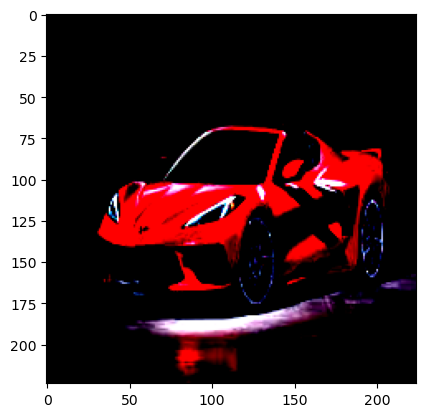

In [29]:
plt.imshow(img[0, ...])